## Open-source python routine for polarization vectors mapping
 

In [1]:
# importing necessary libraries
import numpy as np 
import seaborn as sns
import hyperspy.api as hs
import atomap.api as am
from scipy.stats import gaussian_kde
from atomap.tools import remove_atoms_from_image_using_2d_gaussian
import matplotlib.pyplot as plt
import temul.api as tml

In [2]:
# ── Configuration ───────────────────────────────────────────────────────
IMAGE_PATH = r'your_image.jpg'    # <-- set your image path here
sampling, units = 0.01588, 'nm'   # pixel size in nm/px
# ─────────────────────────────────────────────────────────────────────────

s = hs.load(IMAGE_PATH)
if s.data.ndim == 3:
    s.data = np.mean(s.data, axis=2)

s.axes_manager[0].scale = sampling
s.axes_manager[1].scale = sampling
s.axes_manager[0].units = units
s.axes_manager[1].units = units

img = s.data
if img.dtype != np.float32 and img.dtype != np.float64:
    img = img.astype(np.float32)
h, w = img.shape

Detect atom positions in A and give a large separation to avoid multiple detections per atom; we will refine later

In [3]:
A_positions = am.get_atom_positions(s, separation=20) #change separation as needed
subA = am.Sublattice(A_positions, image=img, color="r")
subA.find_nearest_neighbors()
subA.refine_atom_positions_using_2d_gaussian()
A = np.array(subA.atom_positions, dtype=float)

Gaussian fitting:   0%|          | 0/1154 [00:00<?, ?it/s]

Estimate v1 and v2 (the lattice vectors in pixels) from the nearest neighbor displacements; get vectors from A to neighbors, then find two main directions (v1, v2) that represent the lattice vectors; collect neighbor displacements (dx, dy) and their distances r from A atoms to their neighbors; we will analyze this cloud of vectors to find the main lattice directions

In [4]:
disp = []
for atom in subA.atom_list:
    nn = atom.nearest_neighbor_list
    if nn is None:
        continue
    ax, ay = atom.pixel_x, atom.pixel_y
    for n in nn[:6]:  # a few closest neighbors
        dx = n.pixel_x - ax
        dy = n.pixel_y - ay
        r = (dx*dx + dy*dy)**0.5
        if r > 1e-6:
            disp.append([dx, dy, r])
disp = np.array(disp, dtype=float)

Keep only neighbors in a certain range of distances (ex. 20-40% percentil) to remove noise and neighbors that are too close or too far, which may be less relevant for lattice directions

In [5]:
rmin = np.percentile(disp[:,2], 20)
rmax = np.percentile(disp[:,2], 40)
disp = disp[(disp[:,2] >= rmin) & (disp[:,2] <= rmax)]

disp = np.array(disp, dtype=float)

Visualization: cloud of neighbor displacements (dx, dy) from A atoms; we should see two main clusters of vectors corresponding to the two lattice directions 
which will assure us that the estimation of v1 and v2 will be robust; if the cloud is very noisy or isotropic, we may need to adjust the distance filtering or refine A positions more

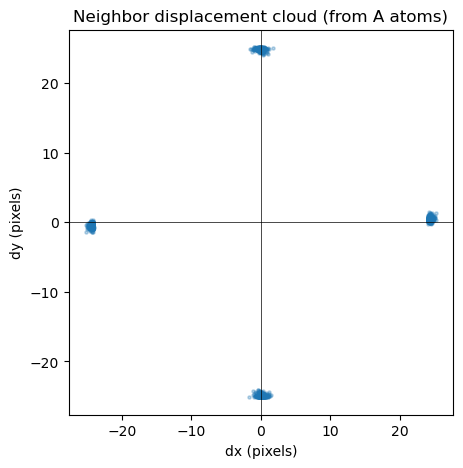

In [6]:
dx = disp[:,0]
dy = disp[:,1]

plt.figure(figsize=(5,5))
plt.scatter(dx, dy, s=5, alpha=0.3)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("dx (pixels)")
plt.ylabel("dy (pixels)")
plt.title("Neighbor displacement cloud (from A atoms)")
plt.show()


In [7]:
# normalize directions
dirs = disp[:, :2]
norm = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / (norm + 1e-9)

Choose v1 as the most frequent direction, and v2 as a direction as different as possible (approximately perpendicular) simple and robust without external clustering

In [8]:
v1_dir = dirs[np.argmax(np.abs(dirs[:,0]))]  
dots = np.abs(dirs @ v1_dir)
v2_dir = dirs[np.argmin(dots)]

# length of vectors v1, v2 (in pixels) from the median of r
a_len = np.median(disp[:,2])
b_len = np.median(disp[:,2])  # in perovskite usually similar; if anisotropic, we can estimate separately

v1 = v1_dir * a_len
v2 = v2_dir * b_len

print("v1 (px):", v1, " |v1|=", np.linalg.norm(v1))
print("v2 (px):", v2, " |v2|=", np.linalg.norm(v2))

v1 (px): [-2.44202072e+01  2.28600353e-04]  |v1|= 24.420207246112124
v2 (px): [-2.27591579e-03 -2.44202071e+01]  |v2|= 24.420207246142343


Generate candidate B positions by shifting A by half of v1 and half of v2; this is a 
common assumption for perovskite-like structures where B atoms are often located at the center of the unit cell defined by A atoms; we will refine these positions later using the image data

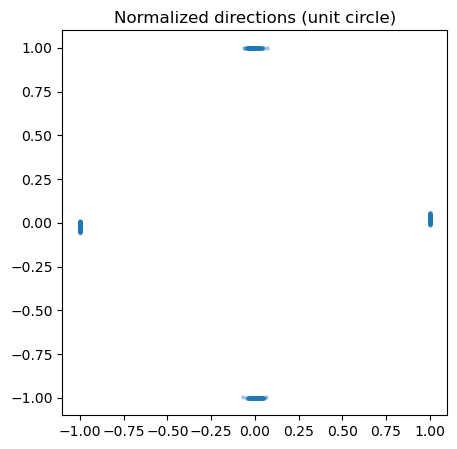

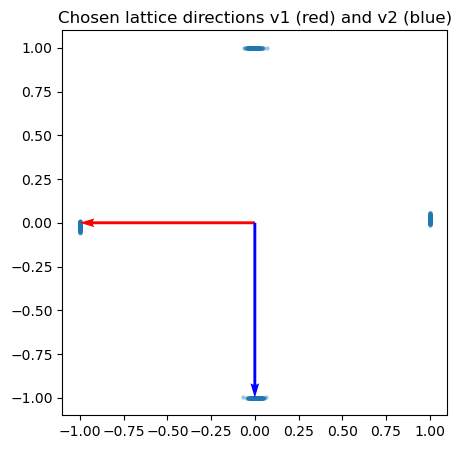

In [9]:
B = A + 0.5*v1 + 0.5*v2
dirs = disp[:, :2]
dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
plt.figure(figsize=(5,5))
plt.scatter(dirs[:,0], dirs[:,1], s=5, alpha=0.3)
plt.gca().set_aspect('equal')
plt.title("Normalized directions (unit circle)")
plt.show()
plt.figure(figsize=(5,5))
plt.scatter(dirs[:,0], dirs[:,1], s=5, alpha=0.3)
plt.quiver(0, 0, v1_dir[0], v1_dir[1], color='r', scale=1, scale_units='xy')
plt.quiver(0, 0, v2_dir[0], v2_dir[1], color='b', scale=1, scale_units='xy')
plt.gca().set_aspect('equal')
plt.title("Chosen lattice directions v1 (red) and v2 (blue)")
plt.show()

Avoid margins where detection is less reliable; we will refine B positions later, so we can afford to lose some candidates at the edges; this also helps to avoid false detections that may appear near the borders of the image due to noise or artifacts

In [10]:
edge = 20  # px
B = B[(B[:,0] > edge) & (B[:,0] < w-edge) & (B[:,1] > edge) & (B[:,1] < h-edge)]

def dedup(points, min_dist=2.5):
    keep = []
    for p in points:
        if all((p[0]-q[0])**2 + (p[1]-q[1])**2 > min_dist**2 for q in keep):
            keep.append(p)
    return np.array(keep, dtype=float)

B = dedup(B, min_dist=2.5)
print("B candidates:", len(B))

B candidates: 1113


Remove A from image and refine B positions using the image data; this is important because the initial B positions are just guesses based on the lattice geometry, and may not be perfectly aligned with the actual B atom positions in the image; by removing the A atoms from the image (using a 2D Gaussian to model their contribution) we can enhance the visibility of B atoms and refine their positions more accurately using either center of mass or 2D Gaussian fitting; this step is crucial for obtaining reliable polarization vectors later on, as it ensures that we are measuring the correct displacements between A and B sublattices 

In [11]:
img_wo_A = remove_atoms_from_image_using_2d_gaussian(subA.image, subA)
min_val = np.min(img_wo_A)
if min_val < 0:
    img_wo_A = img_wo_A - min_val

subB = am.Sublattice(B, image=img_wo_A, color="b")
subB.find_nearest_neighbors()

Subtracting atoms:   0%|          | 0/1154 [00:00<?, ?it/s]

Refine B positions using both methods; we can compare the results to check for consistency; if they are similar, it increases our confidence in the refined positions; if they differ significantly, it may indicate that the refinement is not reliable, and we may need to adjust parameters or investigate further

In [12]:
try:
    subB.refine_atom_positions_using_center_of_mass()
except Exception as e:
    print("COM refinement for B failed:", e)

try:
   subB.refine_atom_positions_using_2d_gaussian()
except Exception as e:
  print("Gaussian refinement for B failed:", e)

Center of mass:   0%|          | 0/1113 [00:00<?, ?it/s]

Gaussian fitting:   0%|          | 0/1113 [00:00<?, ?it/s]

Visualize A and B positions on the original image; this helps to verify that the detected and refined positions of A and B atoms are reasonable and correspond to the actual atomic columns in the image; if the points are well-aligned with the bright spots in the image, it increases our confidence in the subsequent analysis of polarization vectors; if there are significant misalignments, it may indicate issues with detection or refinement that need to be addressed before proceeding

Text(0.5, 1.0, 'A (red) and B (center, blue)')

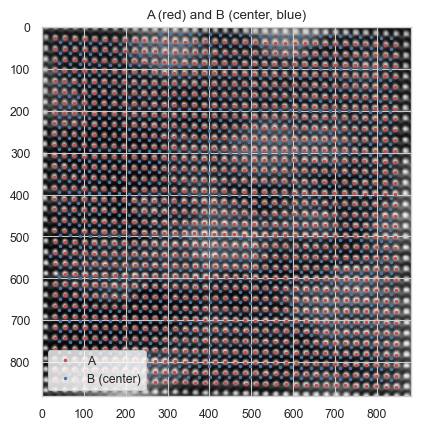

In [146]:
plt.figure()
plt.imshow(img, cmap="gray")
plt.plot(subA.atom_positions[:,0], subA.atom_positions[:,1], "r.", ms=3, label="A")
plt.plot(subB.atom_positions[:,0], subB.atom_positions[:,1], "b.", ms=3, label="B (center)")
plt.legend()
plt.title("A (red) and B (center, blue)")

We can also visualize the ellipticity maps for A and B sublattices; this can help to identify any anisotropy in the atomic columns, which may be related to polarization or other structural features; by comparing the ellipticity maps of A and B, we can gain insights into how the two sublattices differ in terms of their local environment and potential distortions; this information can be valuable for understanding the material's properties and behavior at the atomic level

C:\Users\Cosmin\AppData\Local\Temp\ipykernel_13852\1743630592.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Cosmin\AppData\Local\Temp\ipykernel_13852\1743630592.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Sublattice B ellipticity')

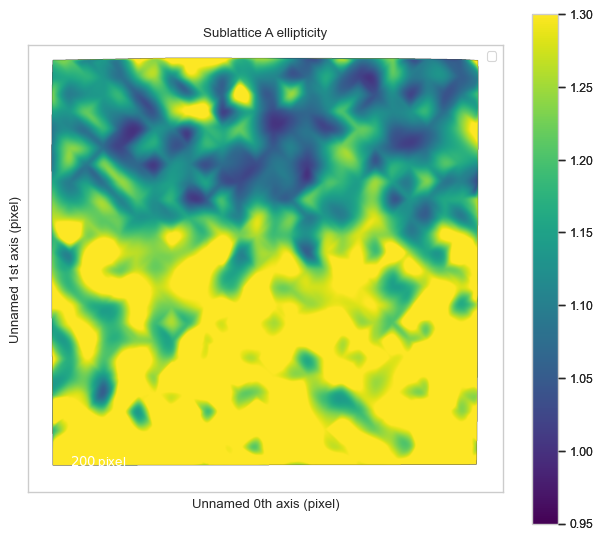

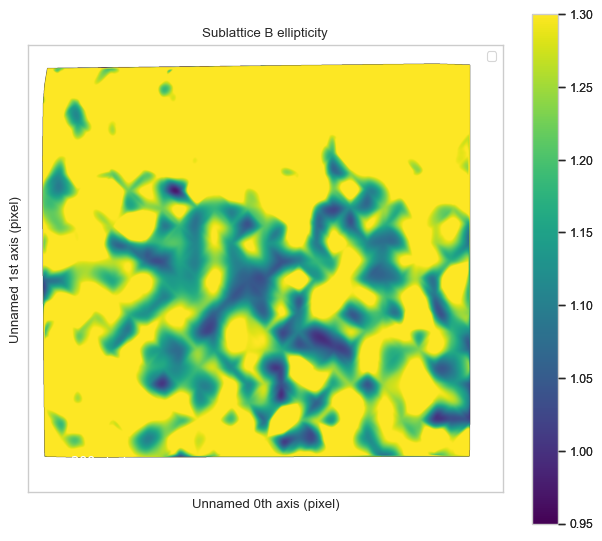

In [96]:
subA.plot_ellipticity_map(cmap='viridis', vmin=0.95, vmax=1.3)
plt.legend()
plt.title('Sublattice A ellipticity')
subB.plot_ellipticity_map(cmap='viridis', vmin=0.95, vmax=1.3)
plt.legend()
plt.title('Sublattice B ellipticity')

Zone axes from A; this is important because the zone axes (za0, za1) represent the average directions of the atomic columns in the A sublattice, and are used as reference directions for calculating the polarization vectors between A and B sublattices; by constructing the zone axes from A, we can ensure that we are using the correct crystallographic directions.
Calculate the angle between za0 and za1; this is important because the angle between the zone axes (za0, za1)  can provide insights into the crystallographic orientation and symmetry of the sample; if the angle is close to 90 degrees, it may indicate a high-symmetry orientation, while deviations from 90 degrees can suggest distortions or lower symmetry; understanding the relationship between the zone axes is crucial for interpreting the polarization vectors and their relation to the underlying crystal structure

In [13]:
subA.construct_zone_axes()
za0, za1 = subA.zones_axis_average_distances[0:2]

v0 = np.array(za0, float)
v1 = np.array(za1, float)
ang = np.degrees(np.arccos(np.clip(np.dot(v0, v1) / (np.linalg.norm(v0)*np.linalg.norm(v1)), -1, 1)))
print("Angle between za0 and za1:", ang)

Angle between za0 and za1: 88.88068288595211


Get polarization vectors from A to B; this is the key step where we calculate the polarization vectors based on the refined positions of A and B atoms, and the zone axes from A;


In [14]:
s_p = subA.get_polarization_from_second_sublattice(
    za0, za1, subB
)


Extract vectors; this is important because the vector_list contains the calculated polarization vectors between the A and B sublattices, which are essential for analyzing the local polarization behavior in the material; by extracting these vectors, we can visualize and further analyze the polarization patterns, which can provide insights into the material's properties and potential applications

In [15]:

vector_list = s_p.metadata.vector_list
x = [i[0] for i in vector_list]      
y = [i[1] for i in vector_list]
u = [i[2] for i in vector_list]
v = [i[3] for i in vector_list]

Histograms of magnitude and angle of polarization vectors; this is important for analyzing the distribution of polarization magnitudes and angles in the sample, which can provide insights into the local structural distortions and domain configurations; by plotting histograms of the magnitudes and angles, we can identify any preferred orientations or characteristic magnitudes of the polarization vectors, which may be related to the underlying crystal structure, defects, or external influences; this analysis can help us understand the material's properties and behavior at the nanoscale

Magnitude (nm): min/median/max = 0.029934180142260514 0.061141053336201484 0.08170234482957667


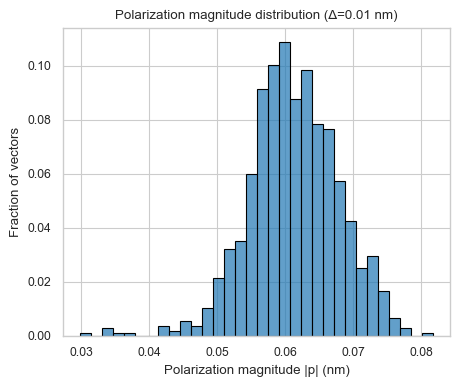

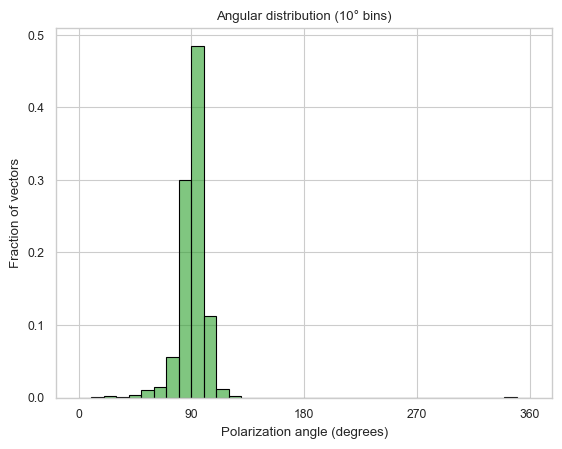

In [16]:

u_arr = np.array(u, dtype=float)
v_arr = np.array(v, dtype=float)

# Magnitude in nm
mag_nm = np.sqrt(u_arr**2 + v_arr**2) * sampling

# Angle in degrees (-180..180)
angle_deg = np.degrees(np.arctan2(v_arr, u_arr))

# Optional: if you care about orientation only (p and -p equivalent), fold to [-90, 90)
# Optional: remove extreme outliers (helps cleaner histograms)
L = mag_nm
med = np.median(L)
mad = np.median(np.abs(L - med)) + 1e-12
keep = L < (med + 6 * mad)
mag_nm = mag_nm[keep]
angle_deg = angle_deg[keep]

print("Magnitude (nm): min/median/max =", mag_nm.min(), np.median(mag_nm), mag_nm.max())
sns.set(style="whitegrid", context="paper")

bin_width = 0.01  # nm
bins = np.arange(0, mag_nm.max() + bin_width, bin_width)

plt.figure(figsize=(5,4))
sns.histplot(
    mag_nm,
    # bins=bins,
    stat="probability",
    kde=False,               #KDE can be misleading for small datasets or if the distribution is not smooth; 
    # it may create artificial peaks or smooth out important features in the histogram; by setting kde=False, we can focus on the actual distribution of the data without introducing potential artifacts from KDE smoothing;
    color="tab:blue",
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Polarization magnitude |p| (nm)")
plt.ylabel("Fraction of vectors")
plt.title("Polarization magnitude distribution (Δ=0.01 nm)")
plt.show()
angle_360 = np.mod(angle_deg, 360)
bins = np.arange(0, 365, 10)  # 10° per bin

sns.histplot(
    angle_360,
    bins=bins,
    stat="probability",
    color="tab:green",
    edgecolor="black",
    alpha=0.6
)

plt.xlabel("Polarization angle (degrees)")
plt.ylabel("Fraction of vectors")
plt.xticks([0, 90, 180, 270, 360])
plt.title("Angular distribution (10° bins)")
plt.show()

We can use temul's built-in function to plot polarization vectors as arrows on top of the image, colored by their magnitude or angle;
this provides a visual representation of the local polarization patterns in the sample, allowing us to see how the polarization vectors are distributed spatially and how they relate to the underlying atomic structure; but temul library is not very flexible for styling, so we can also plot using matplotlib for more control over the appearance of the vectors and the colormap;

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'frameon'

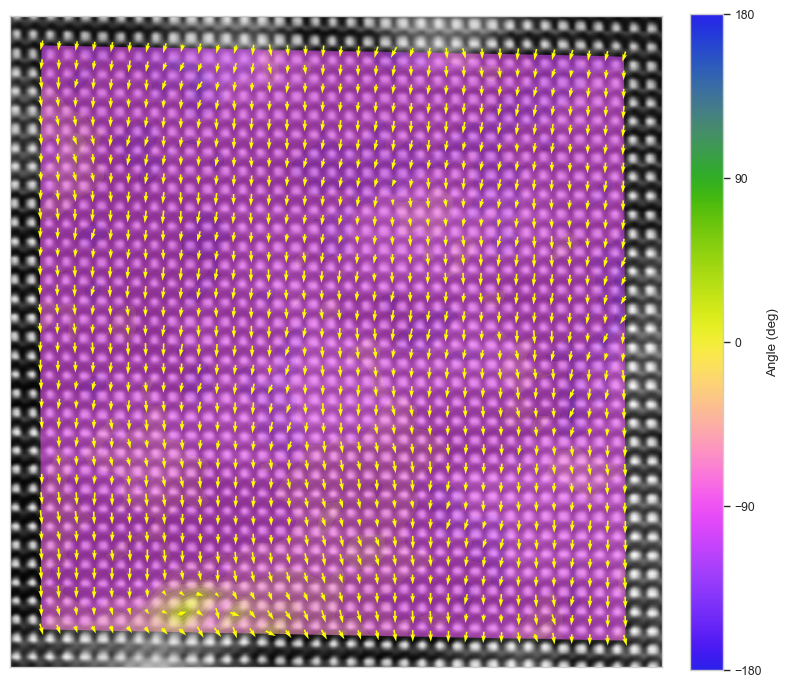

In [17]:

tml.plot_polarisation_vectors(
    x, y, u, v,
    image=img,
    sampling=sampling,
    plot_style='contour',
    overlay=True,
    vector_rep="angle",
    degrees=True,
    cmap='cet_colorwheel',
    levels=32,
    antialiased=True,
    alpha=0.6,
    remove_vectors=False,
    ticks=[-180, -90, 0, 90, 180]
)

plt.show()


Plotting polarization vectors colored by magnitude using matplotlib; this is important for visualizing the spatial distribution of polarization vectors and their magnitudes across the sample, which can reveal patterns, domains, or correlations with structural features;

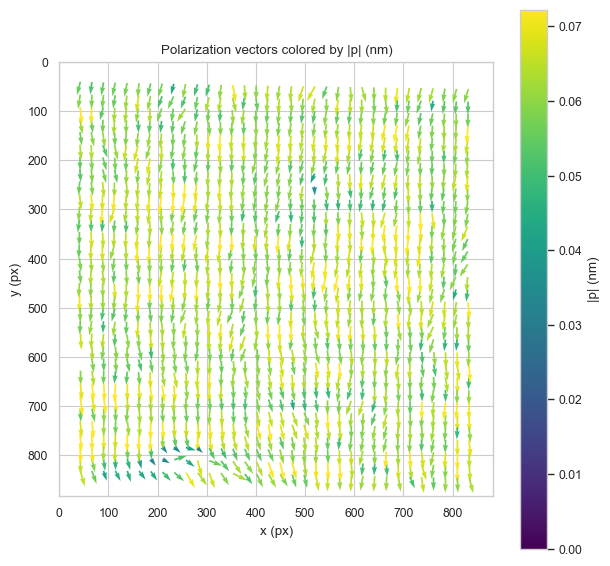

In [152]:
x = np.array(x, float)
y = np.array(y, float)
u = np.array(u, float)
v = np.array(v, float)

mag_nm = np.sqrt(u*u + v*v) * sampling  # sampling in nm/px
vmax = np.percentile(mag_nm, 95) #optional: limit the maximum magnitude for better color scaling; this can help to visualize the distribution of magnitudes more clearly, 

fig, ax = plt.subplots(figsize=(7, 7))

VIS = 8  # only for visualization, not affecting the actual vector magnitudes
q = ax.quiver(
    x, y,
    u * VIS, v * VIS,          
    mag_nm,                  # color = magnitude in nm
    angles='xy',
    scale_units='xy',
    scale=1,       # important to set scale=1 when using scale_units='xy' to ensure that the arrow lengths correspond directly to the u and v values;
    cmap='viridis',
    width=0.004
)
q.set_clim(0, vmax)

ax.set_xlim(0, img.shape[1])
ax.set_ylim(img.shape[0], 0)   
ax.set_aspect('equal')

ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
ax.set_title("Polarization vectors colored by |p| (nm)")

cbar = plt.colorbar(q, ax=ax)
cbar.set_label("|p| (nm)")

plt.show()


Plotting with variable transparency based on magnitude; this can help to visually emphasize stronger polarization vectors while still showing the weaker ones without overwhelming the plot; by adjusting the alpha values, we can create a more informative and visually appealing representation of the polarization vector field;

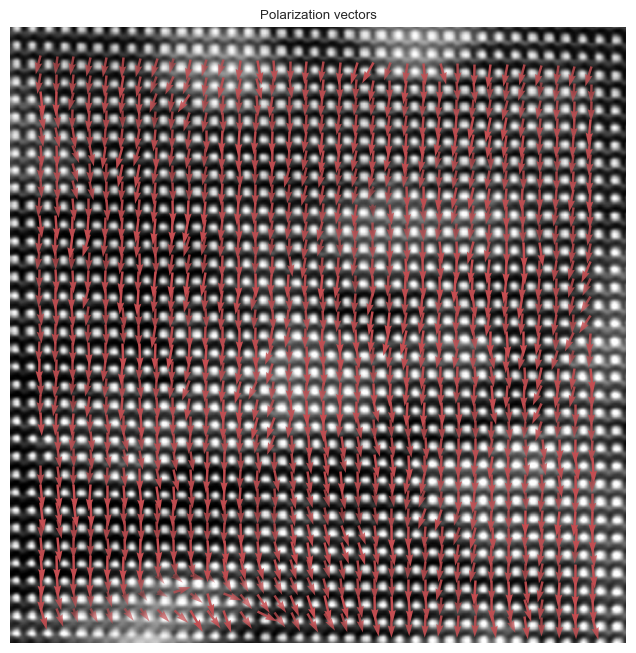

In [155]:
alpha = np.clip(mag_nm / np.percentile(mag_nm, 95), 0.2, 1.0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap='gray', vmin=np.percentile(img,1), vmax=np.percentile(img,99))
VIS=8  # scaling factor for visualization; adjust as needed to make the arrows visible without overwhelming the image;
for xi, yi, ui, vi, a in zip(x, y, u, v, alpha):
    ax.quiver(
        xi, yi,
        ui * VIS, vi * VIS,
        color='r',        # red with variable transparency
        alpha=a,
        angles='xy',
        scale_units='xy',
        scale=1,
        width=0.004
    )

ax.set_title('Polarization vectors')
ax.axis('off')
plt.show()

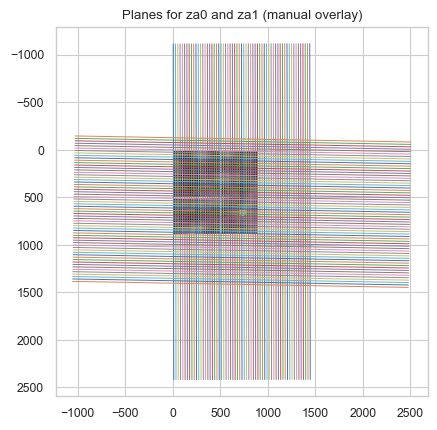

In [127]:
def plot_planes_two_axes(image, origin_xy, za0, za1, spacing0=None, spacing1=None, n_lines=30):
  
    h, w = image.shape
    ox, oy = origin_xy

    v0 = np.array(za0, float)
    v1 = np.array(za1, float)

    if spacing0 is None:
        spacing0 = np.linalg.norm(v0)
    if spacing1 is None:
        spacing1 = np.linalg.norm(v1)

    
    dir_line0 = v1 / (np.linalg.norm(v1) + 1e-9)
    dir_line1 = v0 / (np.linalg.norm(v0) + 1e-9)

    fig, ax = plt.subplots()
    ax.imshow(image, cmap="gray")
    ax.plot(ox, oy, "yo", ms=4)

    
    n0 = np.array([-dir_line0[1], dir_line0[0]])
    n1 = np.array([-dir_line1[1], dir_line1[0]])

    L = max(h, w) * 2  
    for k in range(-n_lines, n_lines + 1):
        p = np.array([ox, oy]) + k * spacing0 * n0
        p1 = p - L * dir_line0
        p2 = p + L * dir_line0
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "-", linewidth=0.7)

    for k in range(-n_lines, n_lines + 1):
        p = np.array([ox, oy]) + k * spacing1 * n1
        p1 = p - L * dir_line1
        p2 = p + L * dir_line1
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "-", linewidth=0.7)

    ax.set_title("Planes for za0 and za1 (manual overlay)")
    plt.show()
za0, za1 = subA.zones_axis_average_distances[0:2]
origin = subA.atom_positions[0]  

plot_planes_two_axes(img, origin, za0, za1)
plt.show()